In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression

# Display plots
%matplotlib inline

In [12]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Classroom/agriculture_yield_dataset.csv')

# Number of rows and columns
print("Rows and Columns:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# First 10 records
print("\nFirst 10 Records:")
display(df.head(10))

Rows and Columns:
(1500, 8)

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [14]:
 # Data types
print("Data Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Columns containing missing values
missing_cols = df.columns[df.isnull().sum() > 0]

print("\nColumns with Missing Values:")
print(missing_cols.tolist())

Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Columns with Missing Values:
[]


In [16]:
# Summary statistics
summary = df.describe()

print(summary)

# Highest mean
highest_mean = summary.loc['mean'].idxmax()
print("\nFeature with Highest Mean:")
print(highest_mean)

# Highest standard deviation
highest_std = summary.loc['std'].idxmax()
print("\nFeature with Highest Standard Deviation:")
print(highest_std)

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

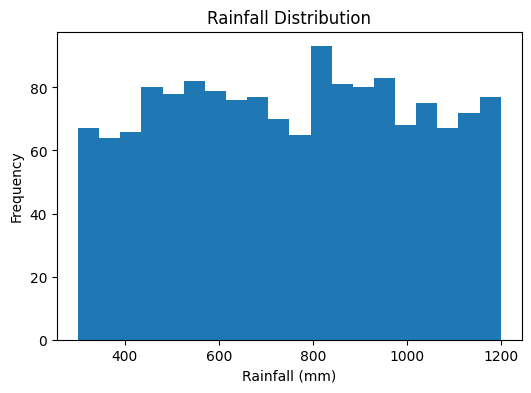

In [18]:
plt.figure(figsize=(6,4))
plt.hist(df['rainfall_mm'], bins=20)
plt.title('Rainfall Distribution')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.show()

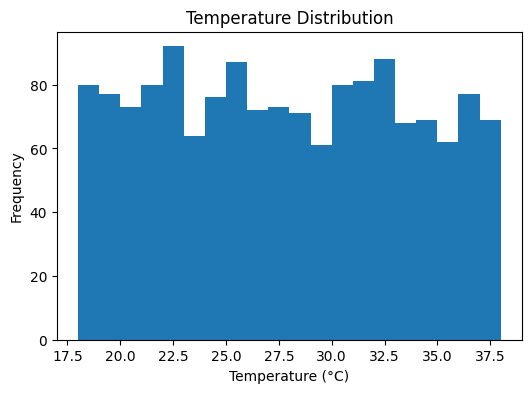

In [20]:
plt.figure(figsize=(6,4))
plt.hist(df['temperature_c'], bins=20)
plt.title('Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

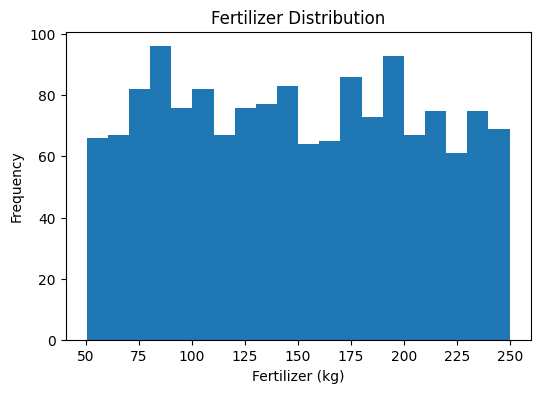

In [22]:
plt.figure(figsize=(6,4))
plt.hist(df['fertilizer_kg'], bins=20)
plt.title('Fertilizer Distribution')
plt.xlabel('Fertilizer (kg)')
plt.ylabel('Frequency')
plt.show()

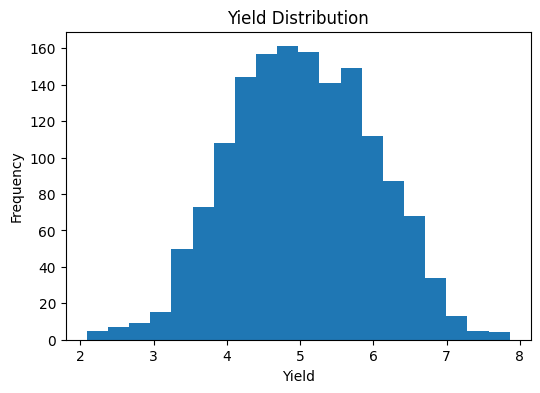

In [24]:
plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins=20)
plt.title('Yield Distribution')
plt.xlabel('Yield')
plt.ylabel('Frequency')
plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


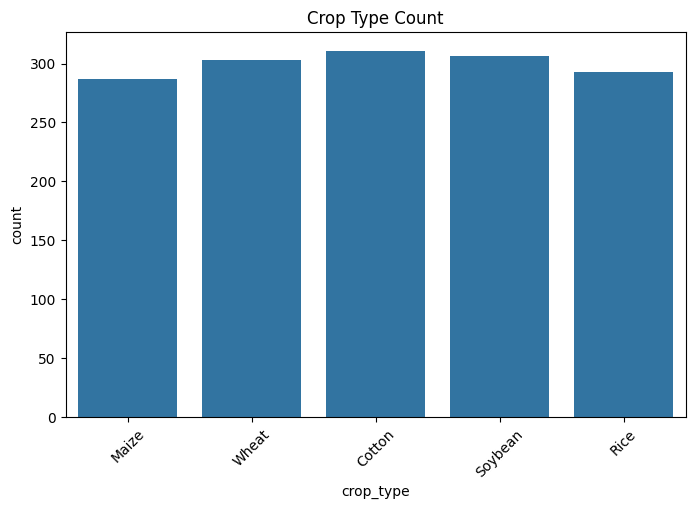


Most Frequent Crop:
Cotton


In [26]:
# Frequency count
crop_counts = df['crop_type'].value_counts()

print(crop_counts)

# Count plot
plt.figure(figsize=(8,5))
sns.countplot(x='crop_type', data=df)
plt.title('Crop Type Count')
plt.xticks(rotation=45)
plt.show()

# Most frequent crop
print("\nMost Frequent Crop:")
print(crop_counts.idxmax())

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


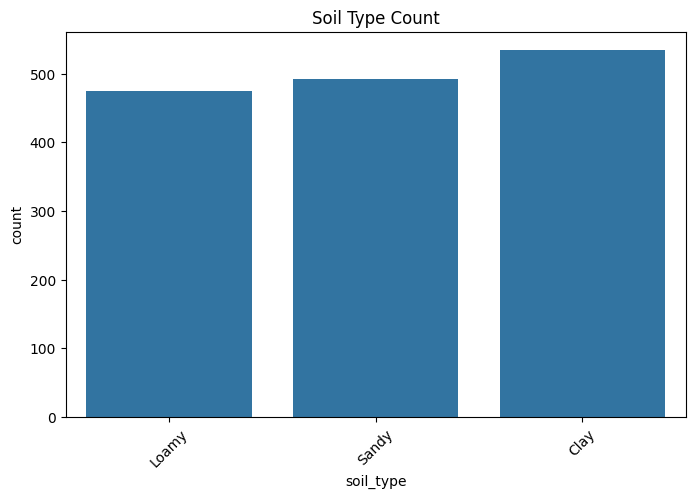


Most Common Soil Type:
Clay


In [28]:
# Frequency count
soil_counts = df['soil_type'].value_counts()

print(soil_counts)

# Count plot
plt.figure(figsize=(8,5))
sns.countplot(x='soil_type', data=df)
plt.title('Soil Type Count')
plt.xticks(rotation=45)
plt.show()

# Most common soil
print("\nMost Common Soil Type:")
print(soil_counts.idxmax())

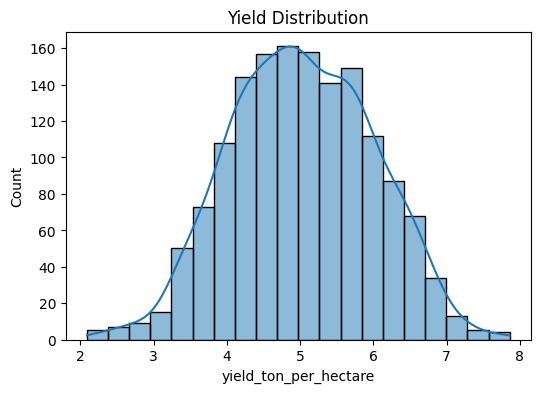

In [30]:
plt.figure(figsize=(6,4))
sns.histplot(df['yield_ton_per_hectare'], bins=20, kde=True)
plt.title('Yield Distribution')
plt.show()

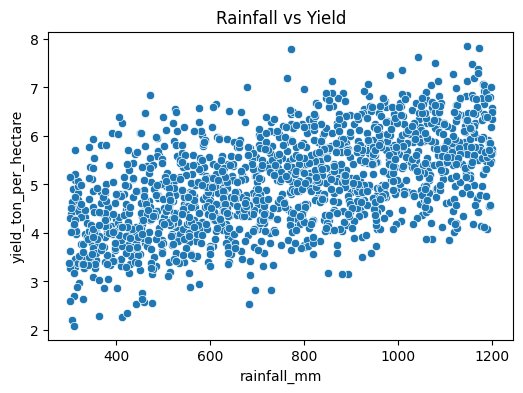

In [32]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='rainfall_mm',
    y='yield_ton_per_hectare',
    data=df
)
plt.title('Rainfall vs Yield')
plt.show()

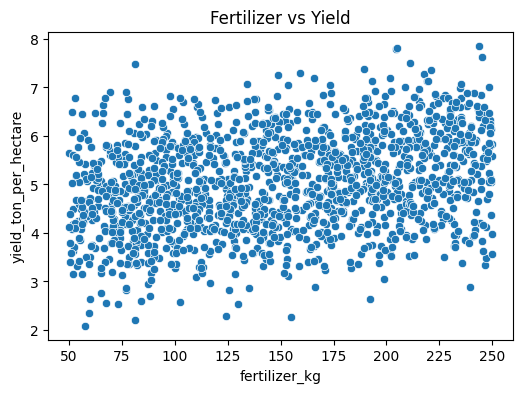

In [34]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='fertilizer_kg',
    y='yield_ton_per_hectare',
    data=df
)
plt.title('Fertilizer vs Yield')
plt.show()

In [36]:
corr_rainfall = df['rainfall_mm'].corr(df['yield_ton_per_hectare'])
corr_fertilizer = df['fertilizer_kg'].corr(df['yield_ton_per_hectare'])

print("Rainfall Correlation:", corr_rainfall)
print("Fertilizer Correlation:", corr_fertilizer)

if abs(corr_rainfall) > abs(corr_fertilizer):
    print("Rainfall has stronger relationship with yield")
else:
    print("Fertilizer has stronger relationship with yield")

Rainfall Correlation: 0.5537042408932247
Fertilizer Correlation: 0.27804258886930494
Rainfall has stronger relationship with yield


                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

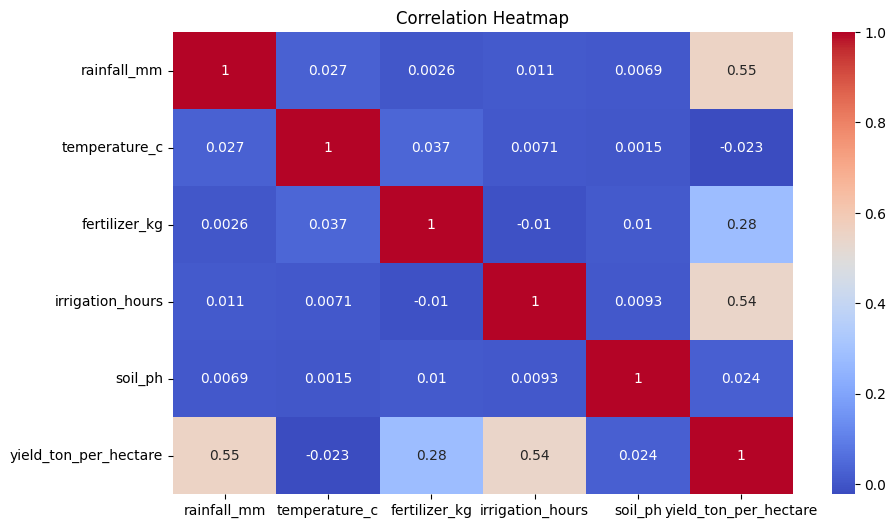

In [38]:
# Numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation matrix
corr_matrix = numeric_df.corr()

print(corr_matrix)

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

In [40]:
yield_corr = corr_matrix['yield_ton_per_hectare']

top3 = yield_corr.abs().sort_values(ascending=False)[1:4]

print("Top 3 Features Correlated with Yield:")
print(top3)

Top 3 Features Correlated with Yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [42]:
crop_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean()

print(crop_yield)

print("\nHighest Yield Crop:")
print(crop_yield.idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Highest Yield Crop:
Rice


In [44]:
soil_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean()

print(soil_yield)

print("\nHighest Yield Soil Type:")
print(soil_yield.idxmax())

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Highest Yield Soil Type:
Loamy


In [46]:
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_cols.tolist())

Categorical Columns:
['crop_type', 'soil_type']


In [48]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("First Five Rows:")
display(df_encoded.head())

First Five Rows:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [50]:
# Target Variable
y = df_encoded['yield_ton_per_hectare']

# Input Features
X = df_encoded.drop('yield_ton_per_hectare', axis=1)

print("Target Variable:")
print("yield_ton_per_hectare")

print("\nFeature Matrix Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

Target Variable:
yield_ton_per_hectare

Feature Matrix Shape:
(1500, 11)

Target Shape:
(1500,)


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (1200, 11)
X_test Shape: (300, 11)
y_train Shape: (1200,)
y_test Shape: (300,)


In [54]:
# Train model
model = LinearRegression()

model.fit(X_train, y_train)

# Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")
display(coefficients.sort_values(
    by='Coefficient',
    ascending=False
))

Intercept:
1.587132027736121

Coefficients:


,Feature,Coefficient
6,crop_type_Rice,0.863993
7,crop_type_Soybean,0.481719
8,crop_type_Wheat,0.348474
9,soil_type_Loamy,0.302974
5,crop_type_Maize,0.238931
3,irrigation_hours,0.198327
2,fertilizer_kg,0.004978
4,soil_ph,0.004901
0,rainfall_mm,0.002035
1,temperature_c,-0.009175


In [56]:
highest_feature = coefficients.loc[
    coefficients['Coefficient'].idxmax()
]

print("Feature with Highest Positive Coefficient:")
print(highest_feature)

Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
